# TF-MInDi Tutorial 3: Visualization and Interpretation

This tutorial covers visualization and biological interpretation:
- Quality assessment plots
- t-SNE visualizations with different color schemes
- Motif logos and pattern visualization
- TF-cell type relationship analysis
- Genomic region annotation

**Prerequisites**: Complete tutorials 1 and 2 first.

In [ ]:
import tfmindi as tm

%matplotlib inline

DATA_DIR = "../../../../data/tfmindi/"

# Load data and patterns
adata_no_na = tm.load_h5ad(DATA_DIR + "seqlets_clustered_no_na.h5ad")

We can also visualize the TF family annotation, noisy seqlet clusters won't have a TF annotation based on majority voting and will thus be annotated as "Unknown".

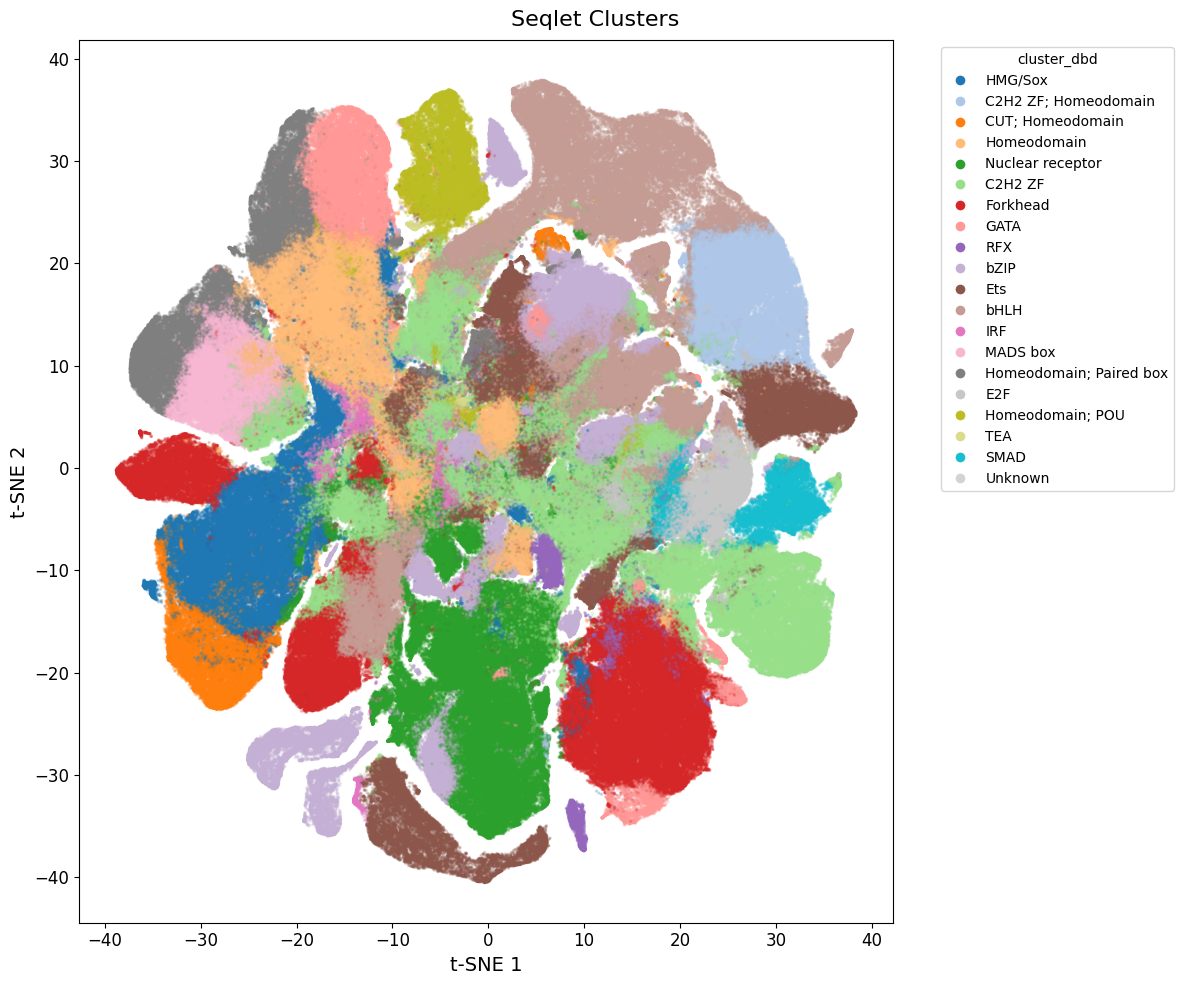

In [ ]:
tm.pl.tsne(
    adata_no_na,
    color_by="cluster_dbd",
    width=12,
    height=10,
    s=2,
    alpha=0.2,
    save_path=DATA_DIR + "seqlets_tsne_cluster_dbd.png",
)

## Second round of clustering

Since we had a fairly strict significance threshold when calling our seqlets (0.05) and our cluster resolution was quite low, we don't have many "Unknown" seqlets clusters.  
Yet, it's still a good idea to omit the clusters that weren't annotated and perform clustering again on this "denoised" dataset. We'll also recluster with a higher resolution to get more fine-grained clusters.   

In [33]:
adata = tm.load_h5ad(DATA_DIR + "seqlets_clustered.h5ad")

In [34]:
adata_no_na = adata[~adata.obs["cluster_dbd"].isna()].copy()

In [35]:
print(f"Ommitting {adata.shape[0] - adata_no_na.shape[0]} seqlets without DBD annotation")

Ommitting 17 seqlets without DBD annotation


In [36]:
tm.tl.cluster_seqlets(adata_no_na, resolution=20.0)  # higher resolution to get more fine-grained clusters

Computing PCA...
Computing neighborhood graph...
Computing t-SNE embedding...
Performing Leiden clustering with resolution 20.0...
Clustering complete. Found 448 clusters.
DBD annotation coverage: 1001933/1007176 seqlets


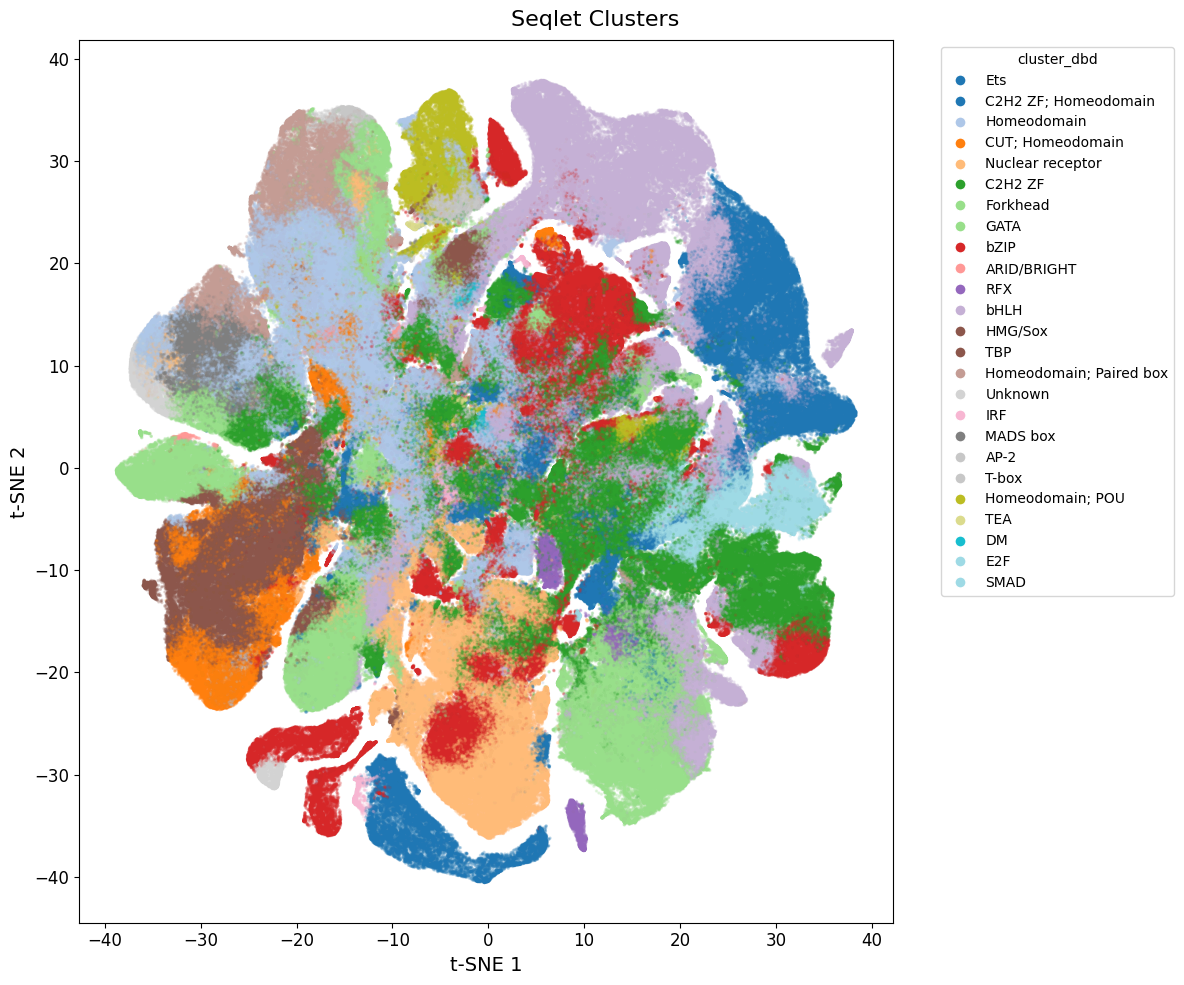

In [37]:
tm.pl.tsne(adata_no_na, color_by="cluster_dbd", width=12, height=10, s=2, alpha=0.2)

In [38]:
tm.save_h5ad(adata_no_na, DATA_DIR + "seqlets_clustered_no_na.h5ad")

## Generating Logos per cluster

Next, we will generate a logo for each cluster of seqlets. For this seqlets per cluster will be aligned using tomtom

In [2]:
adata_no_na = tm.load_h5ad(DATA_DIR + "seqlets_clustered_no_na.h5ad")

In [ ]:
patterns = tm.tl.create_patterns(
    adata_no_na,
    max_n=500,  # sample n seqlets per cluster to speed things up
)

Creating patterns for 448 clusters...


These logo's can now be visualized. For example, on top of the tSNE of seqlets.

In [15]:
# example pattern associated with cluster 72
patterns["72"]

Pattern(cluster=72, n_seqlets=466, len=19, consensus='ATTATGGTCAAGATGTAAA', mean_ic=0.47, dbd=Nuclear receptor)

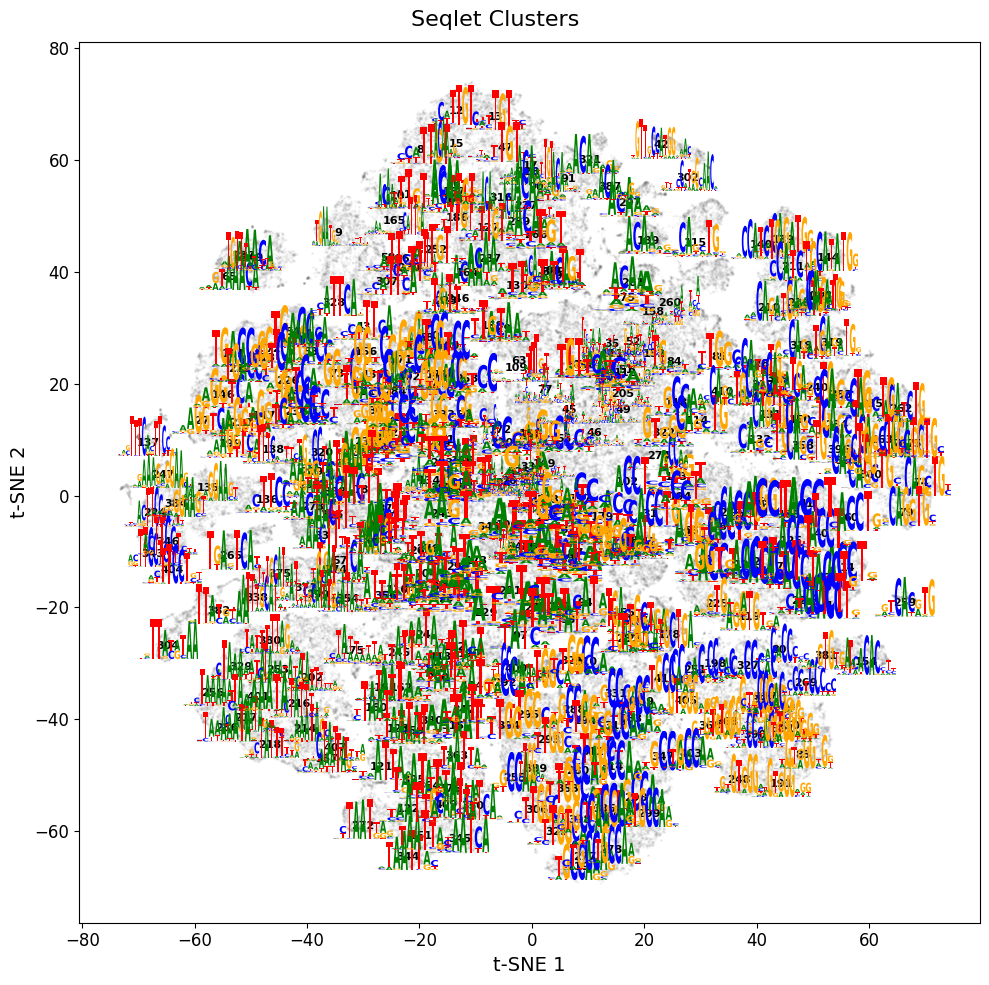

In [16]:
tm.pl.tsne_logos(
    adata_no_na,
    patterns,
    gray_background=True,  # ignore cmap and make all points gray for better visibility
    min_nucleotides=4,  # ignore trimmed patterns less than 4 nucleotides (heterogeneous clusters)
    width=10,
    height=10,
    s=0.5,
    alpha=0.05,
    logo_height=0.4,
    logo_width=0.6,
    ic_threshold=0.2,  # nucleotides in pattern below this will be trimmed
)

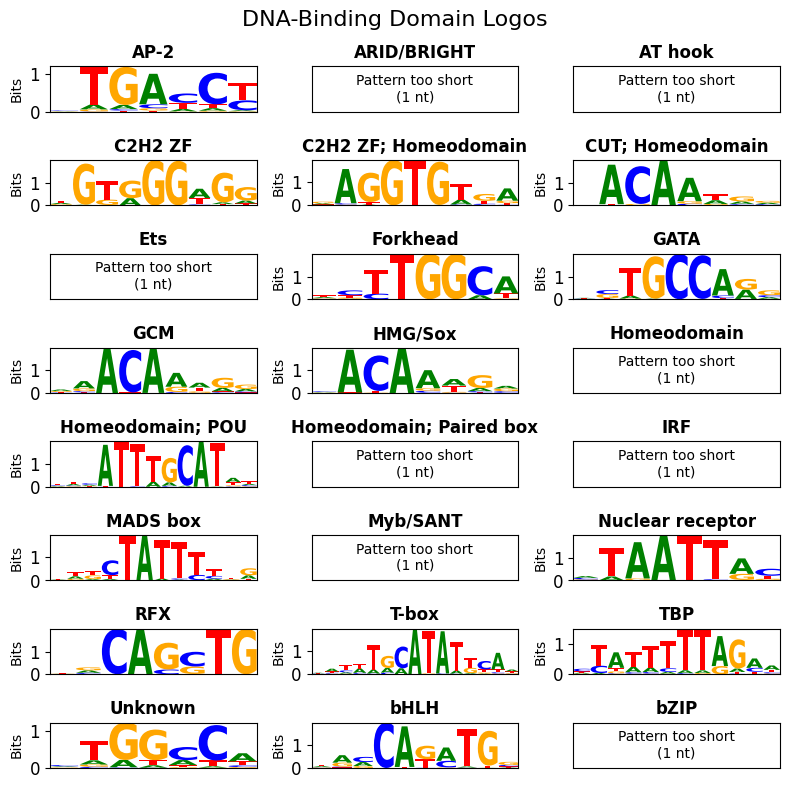

In [17]:
tm.pl.dbd_logos(patterns, ncols=3)

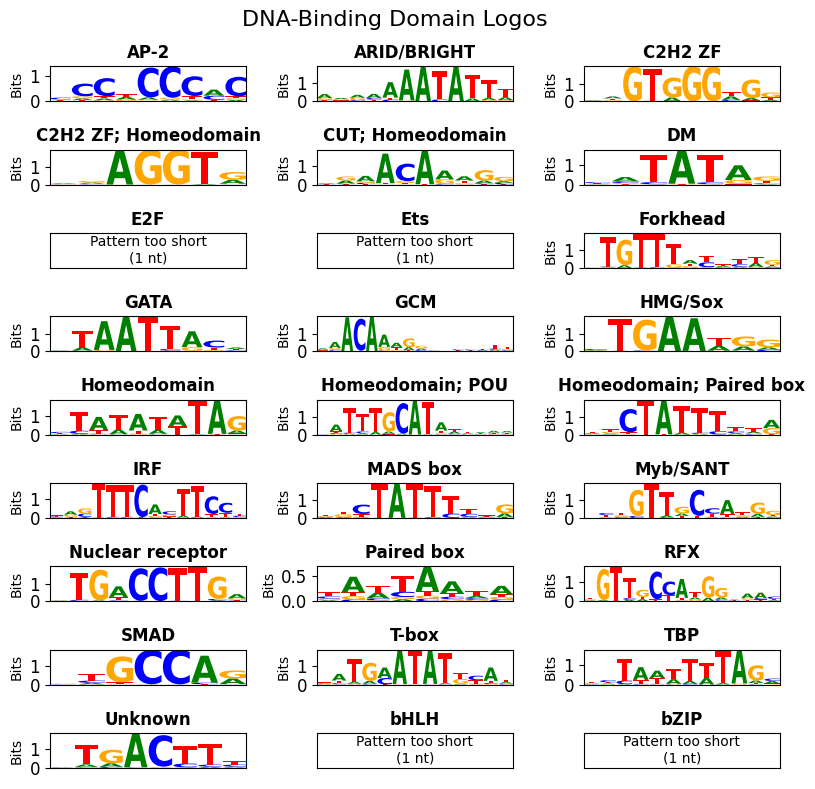

In [27]:
tm.pl.dbd_logos(patterns, ncols=3)

## Investigating DBD - Cell Type relationships

Since we know which seqlet came from which region, and we use regions that are specific to a certain cell type as inputs to the seqlet detection algorithm, we can link each seqlet to a specific cell type.
As we have annotated each seqlet with a DNA-binding-domain through the clusters, we can count the DBD occurence per cell type to investigate the relationship between the two.  
To do this, you need to have passed the `cell_type_mapping` argument when creating the original anndata object using `tm.pp.{func}`.  
Or, you can manually add this cell_type column in your anndata.obs. Then, you'll be able to plot a heatmap using `tm.pl.dbd_heatmap`.

In [18]:
adata_no_na.obs.head(3)  # 'cell_type' column needs to be present

,example_idx,start,end,attribution,p-value,seqlet_matrix,seqlet_oh,example_oh_idx,example_contrib_idx,leiden,mean_contrib,seqlet_dbd,cluster_dbd
0,19895,1096,1121,42.909510,-1.230740e-10,"[[-0.08926727, -0.10968999, -0.15208726, 0.163...","[[0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0,...",0,0,0,0.299525,Rel,HMG/Sox
1,23086,962,979,-28.736305,5.394222e-08,"[[0.040170226, 0.043687627, 0.05887973, -0.023...","[[0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0,...",1,1,1,0.179667,NaN,C2H2 ZF; Homeodomain
2,18255,1020,1038,-34.941820,8.111492e-08,"[[0.15715095, -0.033791617, 0.056597892, 0.021...","[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0,...",2,2,1,0.134993,NaN,C2H2 ZF; Homeodomain


In [19]:
tm.pl.dbd_heatmap(adata_no_na, x_label_rotation=90, width=15, col_cluster=False)

ValueError: Column 'cell_type' not found in adata.obs

/data/groups/vib.ai/stein.aerts/lmahieu/projects/TF-MInDi/src/tfmindi/pl/_utils.py:114: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  fig.tight_layout()


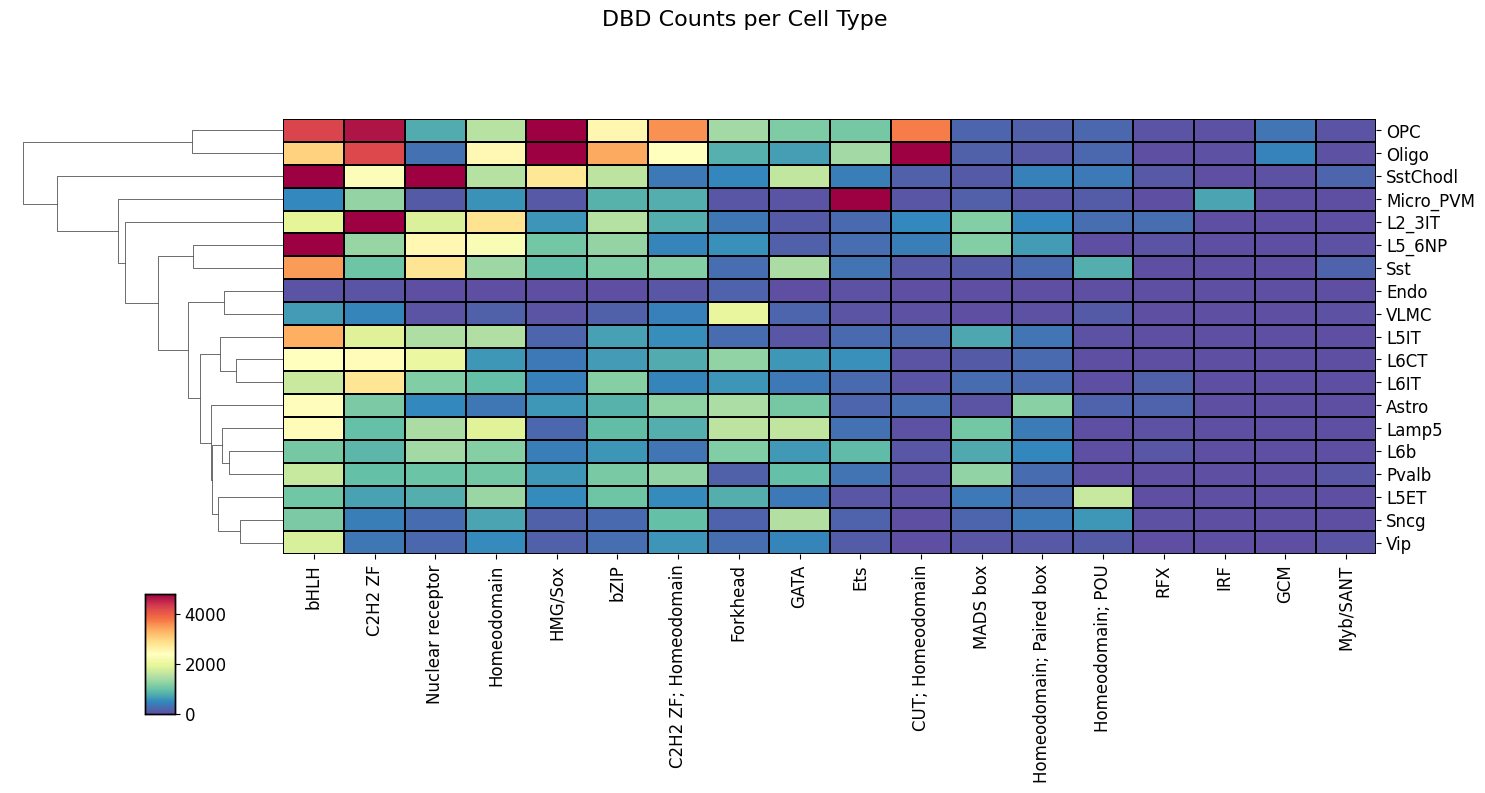

In [7]:
tm.pl.dbd_heatmap(adata_no_na, x_label_rotation=90, width=15, col_cluster=False)

## Annotating TF binding motif instances in genomic regions

As each seqlet is linked to a DBD now, it becomes trivial to highlight the TF binding motif instances in our original genomic regions.  

In [8]:
adata_no_na.obs

,example_idx,start,end,attribution,p-value,seqlet_matrix,seqlet_oh,example_oh,example_contrib,cell_type,leiden,mean_contrib,seqlet_dbd,cluster_dbd
0,19895,1096,1121,42.909510,-1.230740e-10,"[[-0.08926726889774468, -0.10968999050528312, ...","[[0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0,...","[[1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0,...","[[-2.4903556550270878e-05, 9.252861673303414e-...",Oligo,0,0.299525,Rel,C2H2 ZF
1,23086,962,979,-28.736305,5.394222e-08,"[[0.04017022574411184, 0.043687625802597996, 0...","[[0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0,...","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0,...","[[5.913567292736843e-06, 1.5764757336000912e-0...",OPC,1,0.179667,NaN,C2H2 ZF; Homeodomain
2,18255,1020,1038,-34.941820,8.111492e-08,"[[0.1571509604401175, -0.03379161693161631, 0....","[[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0,...","[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[-3.1602667704966336e-10, -1.83534280040476e-...",Oligo,1,0.134993,NaN,C2H2 ZF; Homeodomain
3,19470,1013,1041,42.871715,1.851386e-07,"[[0.011888066848427052, -0.035584272487547766,...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0,...","[[8.473678576592647e-07, 1.0829913890120224e-0...",Oligo,8,0.219323,NaN,CUT; Homeodomain
4,19577,1067,1092,43.687058,2.085394e-07,"[[-0.010883039240813314, -0.077614648090349, 0...","[[0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0,...","[[-6.21854256976917e-09, -1.6329009895343916e-...",Oligo,13,0.238683,NaN,CUT; Homeodomain
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
254835,19518,1162,1173,1.902855,9.904238e-03,"[[-0.2466286429974181, 0.04168630177701599, 0....","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0,...","[[1.5031736211312818e-07, 3.310746023998945e-0...",Oligo,10,0.207374,NaN,HMG/Sox
254836,2308,885,896,2.826526,9.904238e-03,"[[-0.2295182803433148, 0.09578909396416145, -0...","[[0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0,...","[[0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0,...","[[-2.514610514481319e-06, 3.6886378893541405e-...",Sncg,28,0.216507,NaN,Homeodomain; Paired box
254837,13290,940,951,2.854263,9.904238e-03,"[[0.5045523050828915, 0.29473411628280705, -0....","[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0,...","[[4.399502813612344e-06, -1.7323827705695294e-...",SstChodl,66,0.332002,NaN,Myb/SANT
254838,3966,1077,1088,2.360286,9.904238e-03,"[[-0.07374752529903657, -0.009036704810377804,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0,...","[[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0,...","[[7.551758471890935e-07, 5.3053663577884436e-0...",Sncg,72,0.210631,NaN,GATA


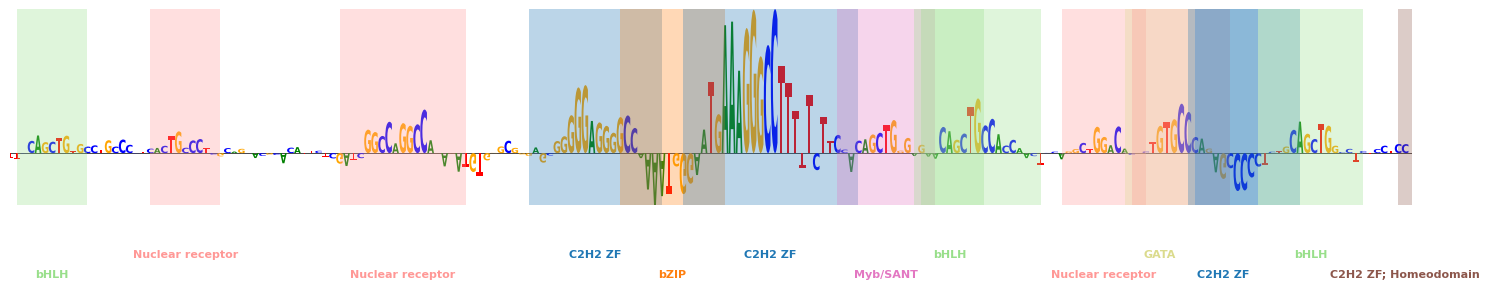

In [14]:
example_idx = 19895  # random region idx
tm.pl.region_contributions(
    adata_no_na,
    example_idx=example_idx,
    zoom_start=1000,
    zoom_end=1200,  # focus on 200bp
    min_attribution=1,  # ignore seqlets below this (absolute) threshold
)